In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("/content/Corona_NLP_train.csv", encoding='latin-1')

In [4]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [5]:
print('Number of rows in data: {}'.format(df.shape[0]))

Number of rows in data: 41157


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


In [8]:
df['Location'].value_counts(ascending = False)

,count
Location,
London,540
United States,528
"London, England",520
"New York, NY",395
"Washington, DC",373
...,...
Staffordshire Moorlands,1
Kithchener ON,1
"Tulsa, Ok",1


In [9]:
df['Sentiment'].value_counts(ascending = False)

,count
Sentiment,
Positive,11422
Negative,9917
Neutral,7713
Extremely Positive,6624
Extremely Negative,5481


<Axes: title={'center': 'Count of Ratings'}, xlabel='Stars'>

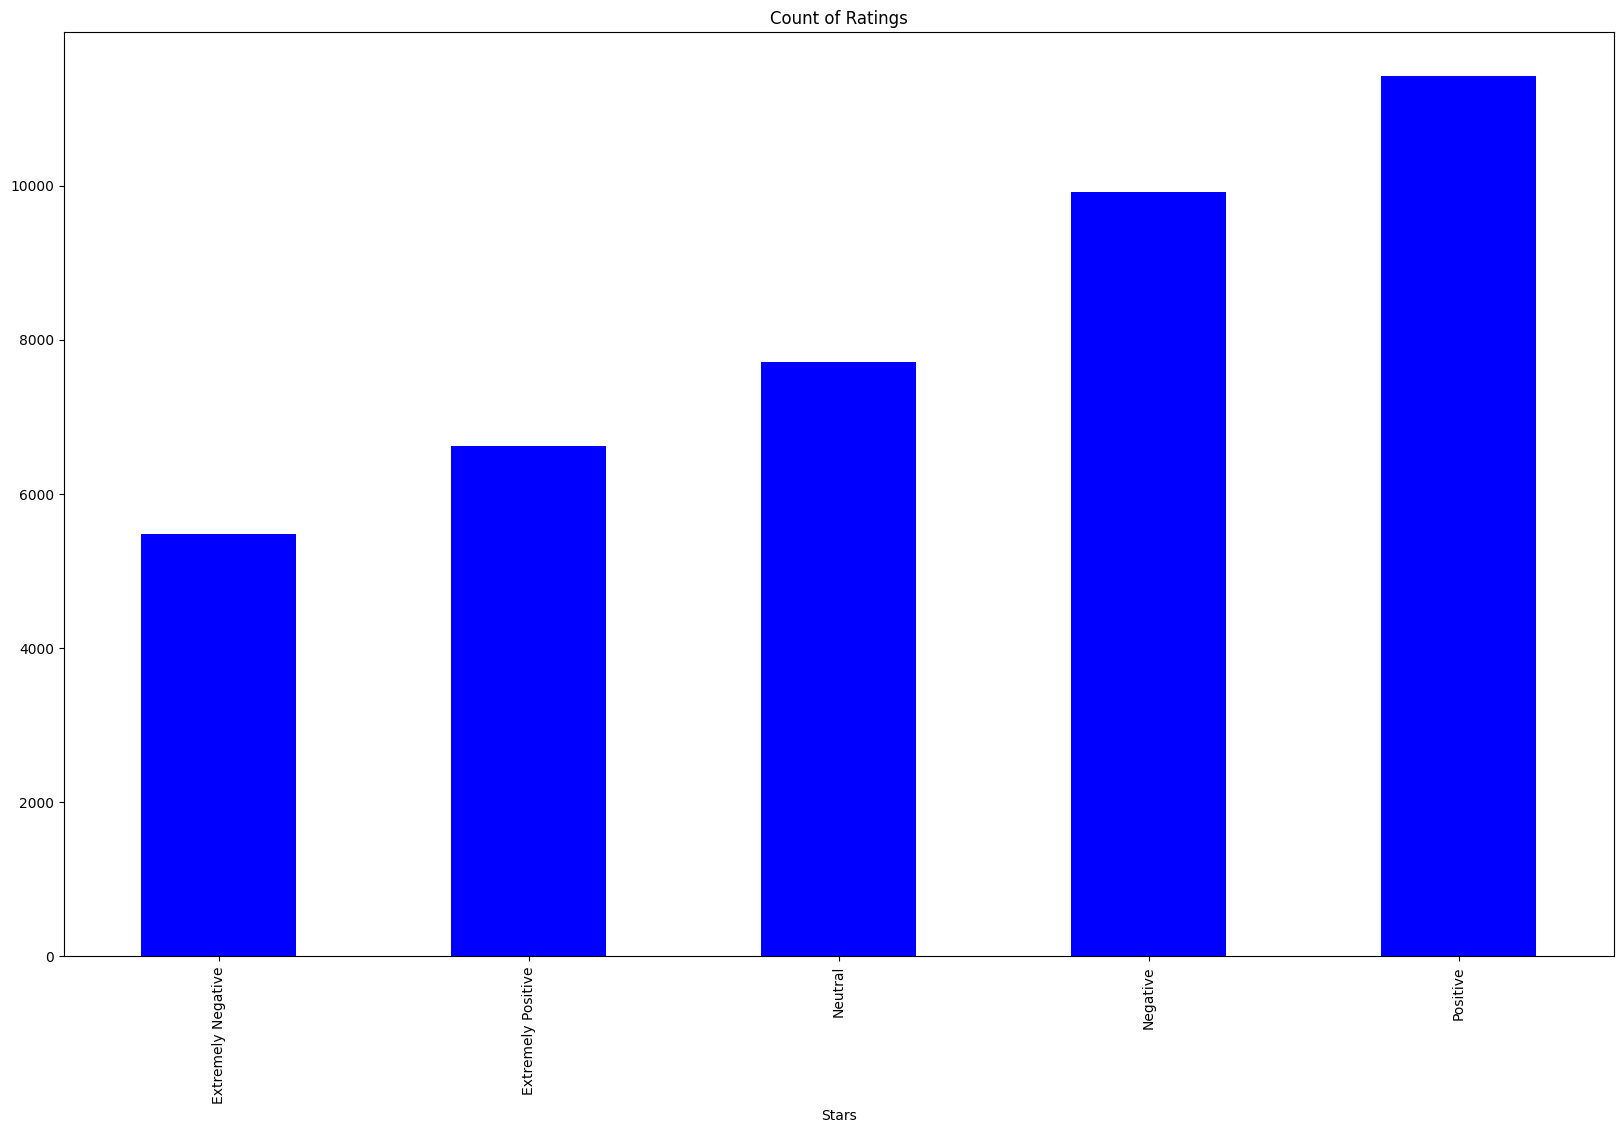

In [11]:
import matplotlib.pyplot as plt
df['Sentiment'].value_counts(ascending = True).plot(kind = 'bar', title = "Count of Ratings", figsize = (20,12), color = 'Blue', xlabel = 'Stars')

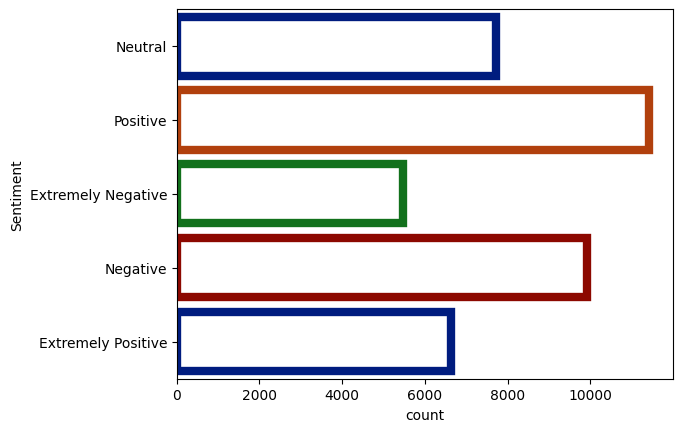

In [13]:
import seaborn as sns
sns.countplot(y = 'Sentiment', data = df, facecolor = (1,1,1,1),linewidth = 6, edgecolor = sns.color_palette("dark",4) )
plt.show()

In [14]:
df.columns

Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')

In [15]:
df.drop(df.columns[[0,1,2,3]], axis = 1, inplace = True)

In [16]:
df.head()

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive
3,My food stock is not the only one which is emp...,Positive
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [17]:
df.isnull().sum()

,0
OriginalTweet,0
Sentiment,0


In [18]:
df.duplicated().sum()

0

In [19]:
blanks = []
for index in df['OriginalTweet']:
  if index.isspace() == True:
    blanks.append(index)

In [20]:
print(blanks)

[]


In [22]:
X = df['OriginalTweet']
y = df['Sentiment']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.33)

In [25]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
textclf = Pipeline([('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

In [30]:
textclf.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', LinearSVC())])

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
preds = textclf.predict(X_test)

In [32]:
print(accuracy_score(y_test, preds))

0.5552937711677219


In [33]:
cm = confusion_matrix(y_test, preds)
print(cm)

[[1106   22  511   51   90]
 [  18 1422   81   47  610]
 [ 623   90 1502  363  683]
 [  46   51  366 1676  494]
 [  93  765  576  460 1836]]


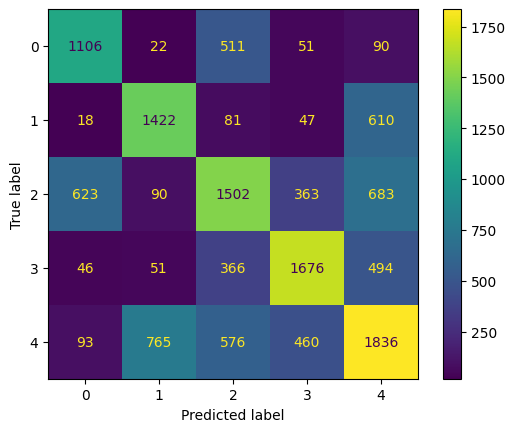

In [34]:
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()


In [35]:
newtweet = [('I am very happy with the coivd control progress.')]

In [39]:
textclf.predict(newtweet)

array(['Extremely Positive'], dtype=object)